# 02 Feature Selection

This notebook focuses on feature selection for the combined crash and road roughness dataset.

The original code cells are preserved. Only Markdown section titles and explanations have been added for GitHub readability.


## 1. Initial Feature Selection Attempt

This section starts the feature selection process for the combined dataset used in crash severity forecasting.


NAASRARoughness: 0.231
IRIRoughness: 0.167
Count_Casualty_Hospitalised: 0.152
Count_Casualty_MedicallyTreated: 0.149
Count_Casualty_Total: 0.128
Count_Casualty_MinorInjury: 0.066
RoughnessSurveyDate: 0.019
Crash_Year: 0.016
Crash_Ref_Number: 0.006
Count_Casualty_Fatality: 0.006
Crash_DCA_Group_Description: 0.004
TDIST_END: 0.003
TDIST_START: 0.003
Crash_DCA_Description: 0.003
APRoad100mID: 0.003
Longitude: 0.003
Crash_Longitude: 0.003
Crash_Nature: 0.003
Crash_Latitude: 0.002
Latitude: 0.002
Count_Unit_Motorcycle_Moped: 0.002
ROAD_SECTION_ID: 0.002
Loc_Post_Code: 0.002
State_Road_Name: 0.002
Count_Unit_Car: 0.002
Crash_DCA_Code: 0.001
CARRIAGEWAY_CODE: 0.001
SEGMENT_LENGTH: 0.001
Loc_Suburb: 0.001
Loc_ABS_Statistical_Area_2: 0.001
Crash_Street_Intersecting: 0.001
Loc_ABS_Statistical_Area_3: 0.001
Crash_Street: 0.001
Loc_ABS_Statistical_Area_4: 0.001
Loc_State_Electorate: 0.001
Loc_Police_Division: 0.001
Count_Unit_Bicycle: 0.001
Crash_Roadway_Feature: 0.001
Loc_Police_District: 0.001
L

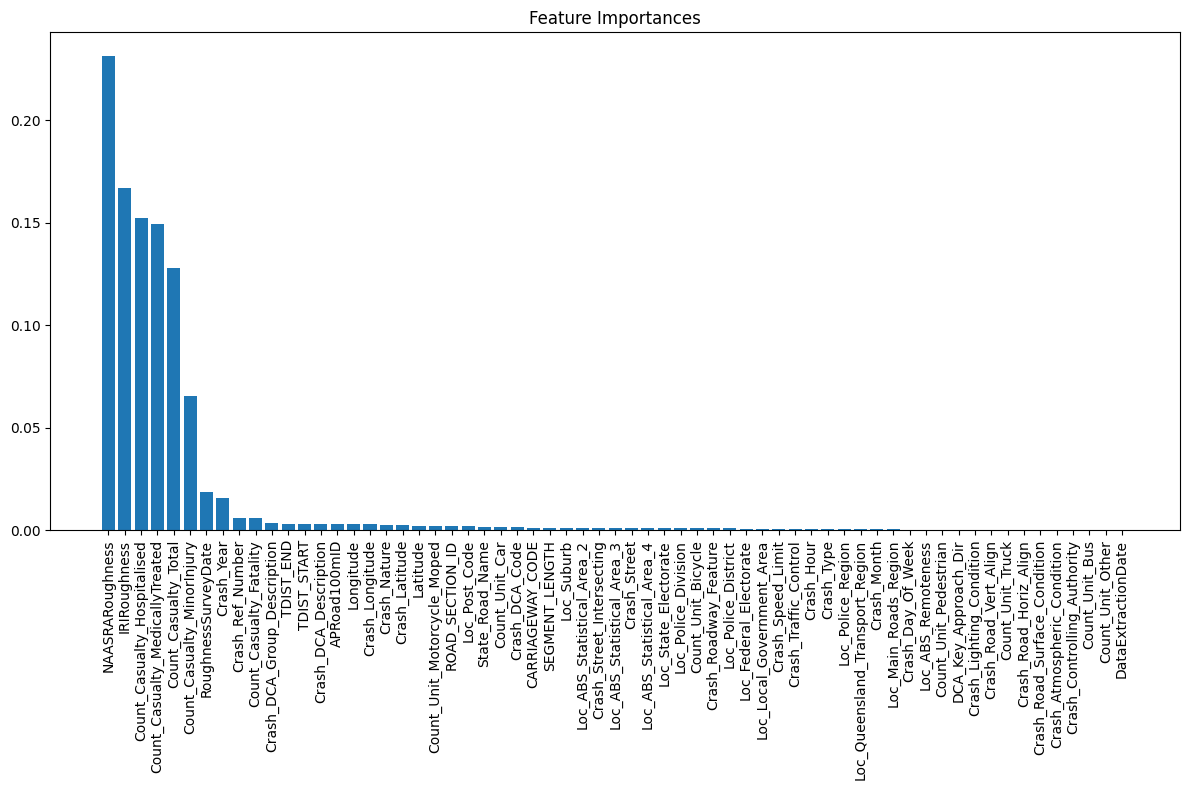

Index(['Crash_Ref_Number', 'Crash_Severity', 'Crash_Year', 'Crash_Month',
       'Crash_Day_Of_Week', 'Crash_Hour', 'Crash_Nature', 'Crash_Type',
       'Crash_Longitude', 'Crash_Latitude', 'Crash_Street',
       'Crash_Street_Intersecting', 'State_Road_Name', 'Loc_Suburb',
       'Loc_Local_Government_Area', 'Loc_Post_Code', 'Loc_Police_Division',
       'Loc_Police_District', 'Loc_Police_Region',
       'Loc_Queensland_Transport_Region', 'Loc_Main_Roads_Region',
       'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3',
       'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness',
       'Loc_State_Electorate', 'Loc_Federal_Electorate',
       'Crash_Controlling_Authority', 'Crash_Roadway_Feature',
       'Crash_Traffic_Control', 'Crash_Speed_Limit',
       'Crash_Road_Surface_Condition', 'Crash_Atmospheric_Condition',
       'Crash_Lighting_Condition', 'Crash_Road_Horiz_Align',
       'Crash_Road_Vert_Align', 'Crash_DCA_Code', 'Crash_DCA_Description',
       'Crash_DCA_Group_De

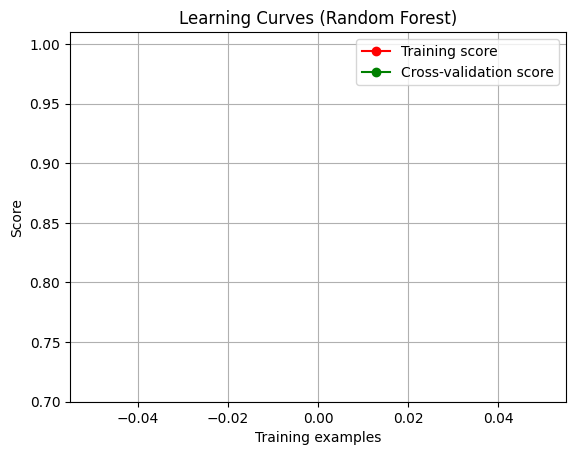

In [19]:

# featrue select combined dataset
#severity forcast (these column not useful)
data = df_cd#.drop(['RoughnessSurveyDate','Crash_Ref_Number', 'Crash_Longitude', 'Crash_Latitude', 'State_Road_Name', 'Loc_Suburb', 'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3', 'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness', 'Count_Unit_Truck', 'Count_Unit_Bus', 'Count_Unit_Bicycle', 'Count_Unit_Pedestrian', 'Count_Unit_Other', 'APRoad100mID'], axis=1)

# data pre processing
# assume all column use encoding(label encoding or one hot encoding? check later(4.21))
# try label, not all column nned encoding
columns_not_to_encode = ['Crash_Year', 'Crash_month','Crash_Hour','NAASRARoughness','IRIRoughness']
label_encoders = {}
for column in data.columns:
    if column not in columns_not_to_encode:
        if data[column].dtype == object:
            le = LabelEncoder()
            data[column] = le.fit_transform(data[column])
            label_encoders[column] = le
#IQR to check the outlier(maybe not need, check later)
"""Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
data = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]"""
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns

# calculate Q1 Q3
Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# based on IQR reduce outlier
data_cleaned = data[~((data[numeric_columns] < (Q1 - 1.5 * IQR)) | (data[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]
# split data
X = data.drop(['Crash_Severity', 'RoughnessClass'], axis=1)  # assume crash_severity   # assume Roughness Class
y = data[['Crash_Severity', 'RoughnessClass']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=10)# use 100, maybe need more
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns
importance_threshold = 0.01
important_indices = importances > importance_threshold
important_features2 = features[important_indices]
important_importances = importances[important_indices]

# sort and print
sorted_indices = importances.argsort()[::-1]
for index in sorted_indices:
    print(f"{features[index]}: {importances[index]:.3f}")
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()
print(df_cd.columns)
#if just crash severity------Count_Casualty_MedicallyTreated
# add rough class NAASRARoughness become first one

title = "Learning Curves (Random Forest)"
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=4)
plt.show()

## 2. Drop Non-useful Columns

This section removes columns that are less useful for crash severity forecasting or are not suitable for modelling.


NAASRARoughness: 0.409
IRIRoughness: 0.362
Crash_Year: 0.064
Crash_DCA_Description: 0.012
Loc_Post_Code: 0.011
TDIST_END: 0.010
ROAD_SECTION_ID: 0.009
Crash_DCA_Code: 0.009
Crash_Nature: 0.009
TDIST_START: 0.009
Crash_Street: 0.008
Crash_Street_Intersecting: 0.008
Crash_DCA_Group_Description: 0.008
Loc_State_Electorate: 0.006
Loc_Police_Division: 0.006
Crash_Hour: 0.005
Loc_Federal_Electorate: 0.005
Loc_Police_District: 0.005
Loc_Local_Government_Area: 0.004
CARRIAGEWAY_CODE: 0.004
Crash_Roadway_Feature: 0.004
Crash_Month: 0.004
Count_Unit_Car: 0.003
Crash_Traffic_Control: 0.003
Crash_Day_Of_Week: 0.003
Crash_Speed_Limit: 0.003
Loc_Police_Region: 0.003
Loc_Queensland_Transport_Region: 0.003
Loc_Main_Roads_Region: 0.002
DCA_Key_Approach_Dir: 0.002
Crash_Lighting_Condition: 0.001
Crash_Type: 0.001
Crash_Road_Vert_Align: 0.001
Crash_Road_Horiz_Align: 0.001
Crash_Road_Surface_Condition: 0.001
Crash_Atmospheric_Condition: 0.001
Crash_Controlling_Authority: 0.000
SEGMENT_LENGTH: 0.000
Count_

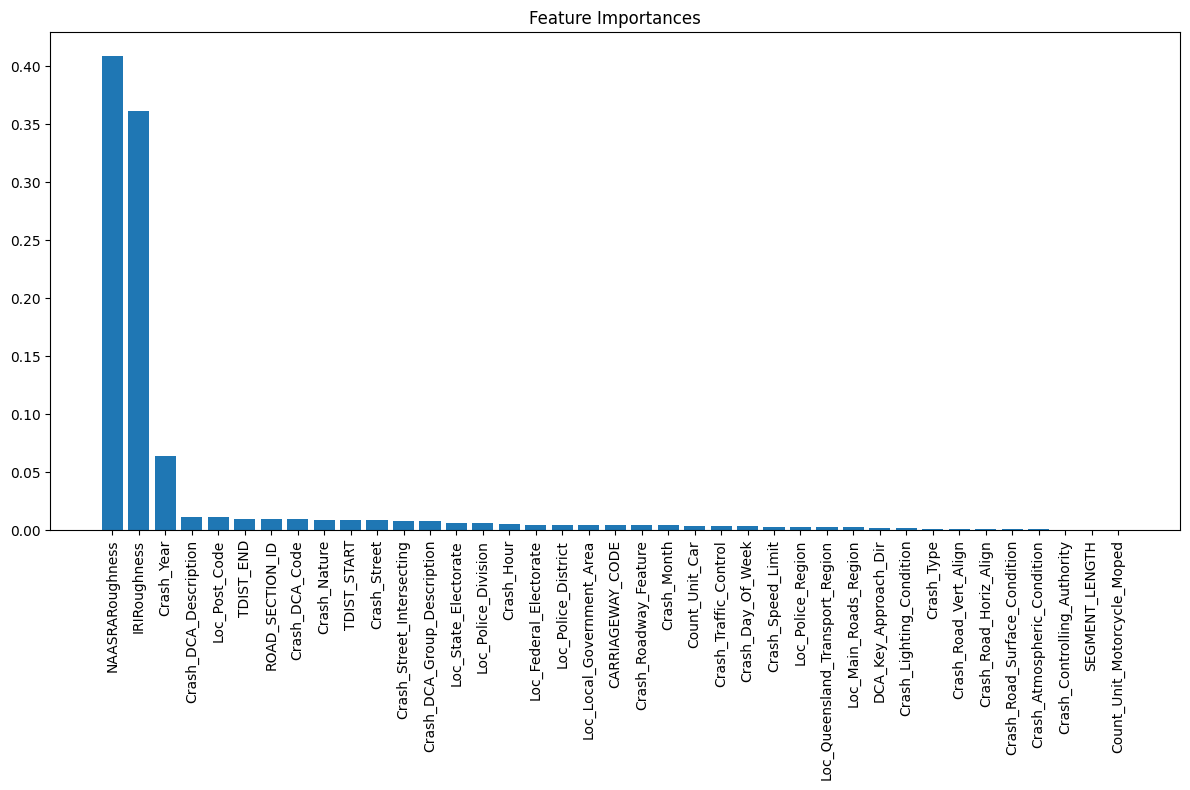

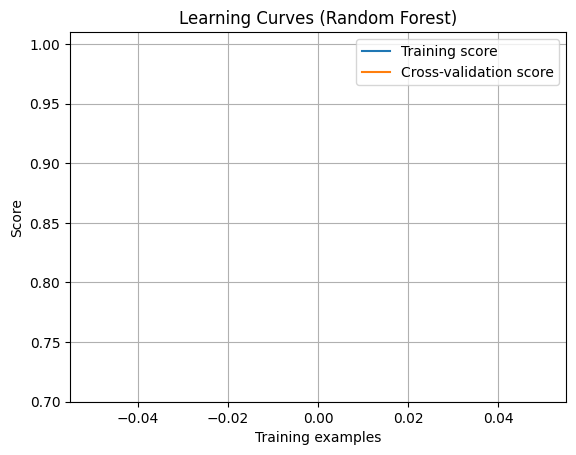

In [ ]:

# Load your data
# df_cd = pd.read_csv('path_to_your_combined_dataset.csv') # Uncomment if loading from file

# Drop columns not useful for severity forecast
data = df_cd.drop([
    'RoughnessSurveyDate', 'Crash_Ref_Number', 'Crash_Longitude', 'Crash_Latitude', 
    'State_Road_Name', 'Loc_Suburb', 'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3', 
    'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness', 'Count_Unit_Truck', 'Count_Unit_Bus', 
    'Count_Unit_Bicycle', 'Count_Unit_Pedestrian', 'Count_Unit_Other', 'APRoad100mID','Count_Casualty_Fatality','Count_Casualty_Hospitalised','Count_Casualty_MedicallyTreated','Count_Casualty_MinorInjury','Count_Casualty_Total','DataExtractionDate','Latitude','Longitude'
], axis=1)

# Data Preprocessing - Label Encoding
columns_not_to_encode = ['Crash_Year', 'Crash_month', 'Crash_Hour', 'NAASRARoughness', 'IRIRoughness']
label_encoders = {}
for column in data.columns:
    if column not in columns_not_to_encode and data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

# IQR-based Outlier Removal
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1
data_cleaned = data[~((data[numeric_columns] < (Q1 - 1.5 * IQR)) | (data[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Split data into features (X) and target (y)
X = data_cleaned.drop(['Crash_Severity', 'RoughnessClass'], axis=1)
y = data_cleaned[['Crash_Severity', 'RoughnessClass']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model Training and Feature Importance
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns

# Feature Importance Threshold and Selection
importance_threshold = 0.01
important_indices = importances > importance_threshold
important_features = features[important_indices]
important_importances = importances[important_indices]

# Sort and Display Feature Importances
sorted_indices = np.argsort(importances)[::-1]
for index in sorted_indices:
    print(f"{features[index]}: {importances[index]:.3f}")

# Plot Feature Importances
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()

# Learning Curve Plotting
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, label="Training score")
    plt.plot(train_sizes, test_scores_mean, label="Cross-validation score")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Define Cross-validation and plot learning curves
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
plot_learning_curve(model, "Learning Curves (Random Forest)", X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=4)


## 3. Final Feature Selection for Modelling

This section further refines the feature set by removing location, reference, and casualty count columns.


Initial Accuracy: 0.3823


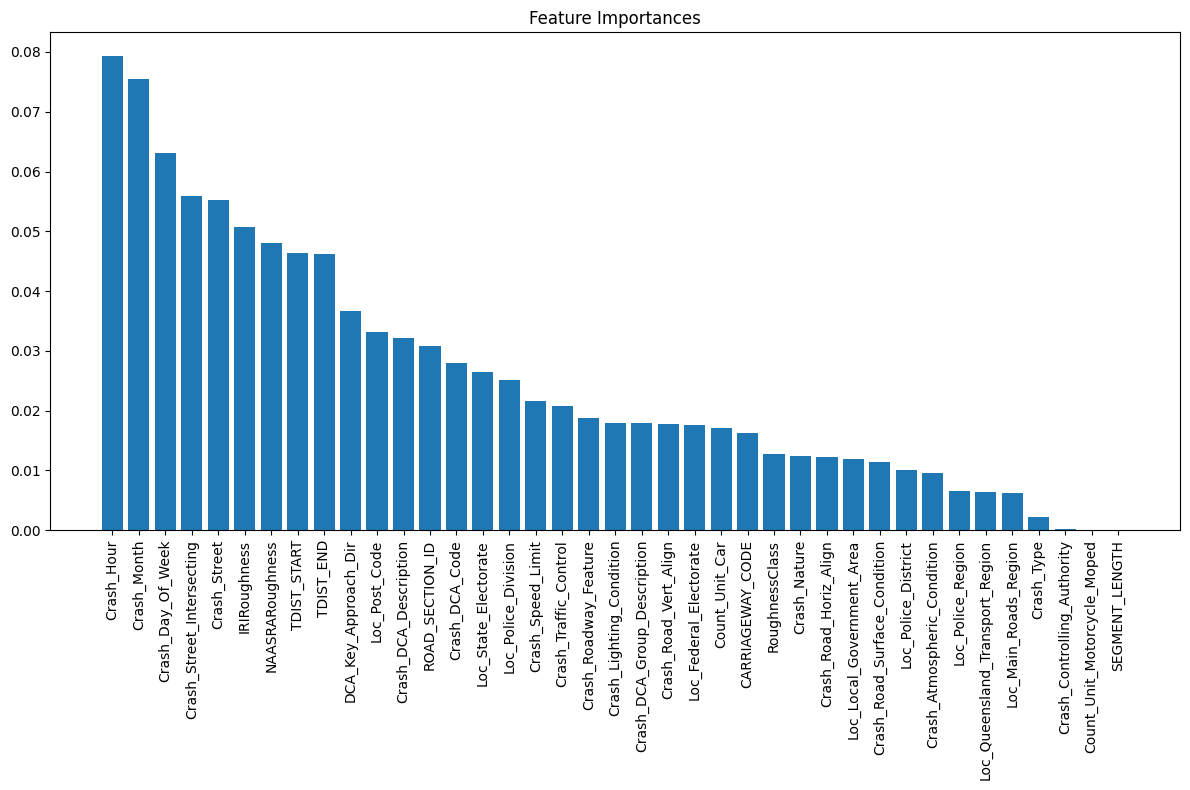

Accuracy after Feature Selection: 0.3661


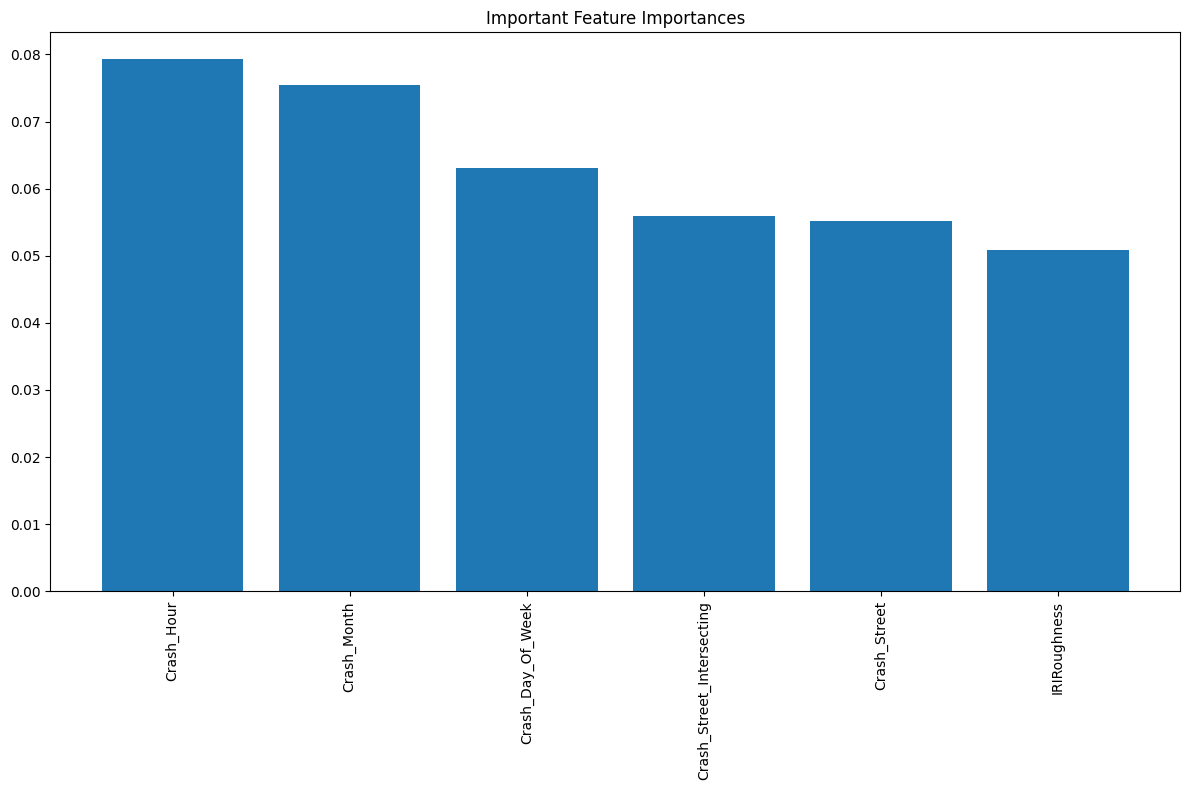

In [ ]:



data = df_cd.drop([
    'RoughnessSurveyDate', 'Crash_Ref_Number', 'Crash_Longitude', 'Crash_Latitude', 
    'State_Road_Name', 'Loc_Suburb', 'Loc_ABS_Statistical_Area_2', 'Loc_ABS_Statistical_Area_3', 
    'Loc_ABS_Statistical_Area_4', 'Loc_ABS_Remoteness', 'Count_Unit_Truck', 'Count_Unit_Bus', 
    'Count_Unit_Bicycle', 'Count_Unit_Pedestrian', 'Count_Unit_Other', 'APRoad100mID','Count_Casualty_Fatality','Count_Casualty_Hospitalised','Count_Casualty_MedicallyTreated','Count_Casualty_MinorInjury','Count_Casualty_Total','DataExtractionDate','Latitude','Longitude','Crash_Year'
], axis=1)
# list no label encoding column
columns_not_to_encode = ['Crash_Year', 'Crash_Month', 'Crash_Hour', 'NAASRARoughness', 'IRIRoughness']

# Label Encoding
label_encoders = {}
for column in data.columns:
    if column not in columns_not_to_encode and data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

# IQR outlier
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# based on IQR reduce outlier
data_cleaned = data[~((data[numeric_columns] < (Q1 - 1.5 * IQR)) | (data[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

# splite the feature and target variable
X = data_cleaned.drop('Crash_Severity', axis=1)  
y = data_cleaned['Crash_Severity']  

# split trainset and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# initial modeling train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# initial modelling evaluation
y_pred = model.predict(X_test)
initial_accuracy = accuracy_score(y_test, y_pred)
print(f"Initial Accuracy: {initial_accuracy:.4f}")

# extract feature importance
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]

# visualisation
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()

# select the important one
importance_threshold = 0.05
important_indices = importances > importance_threshold
important_features = features[important_indices]

# retrain
X_train_important = X_train[important_features]
X_test_important = X_test[important_features]

model_important = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model_important.fit(X_train_important, y_train)

# evaluation
y_pred_important = model_important.predict(X_test_important)
important_accuracy = accuracy_score(y_test, y_pred_important)
print(f"Accuracy after Feature Selection: {important_accuracy:.4f}")

# visualisation
important_importances = importances[important_indices]
sorted_important_indices = important_importances.argsort()[::-1]
plt.figure(figsize=(12, 8))
plt.title('Important Feature Importances')
plt.bar(range(len(important_features)), important_importances[sorted_important_indices], align='center')
plt.xticks(range(len(important_features)), [important_features[i] for i in sorted_important_indices], rotation=90)
plt.tight_layout()
plt.show()




## 4. Review Selected Columns

This cell checks the remaining columns after feature selection.


In [26]:
print(data.columns)


Index(['Crash_Severity', 'Crash_Month', 'Crash_Day_Of_Week', 'Crash_Hour',
       'Crash_Nature', 'Crash_Type', 'Crash_Street',
       'Crash_Street_Intersecting', 'Loc_Local_Government_Area',
       'Loc_Post_Code', 'Loc_Police_Division', 'Loc_Police_District',
       'Loc_Police_Region', 'Loc_Queensland_Transport_Region',
       'Loc_Main_Roads_Region', 'Loc_State_Electorate',
       'Loc_Federal_Electorate', 'Crash_Controlling_Authority',
       'Crash_Roadway_Feature', 'Crash_Traffic_Control', 'Crash_Speed_Limit',
       'Crash_Road_Surface_Condition', 'Crash_Atmospheric_Condition',
       'Crash_Lighting_Condition', 'Crash_Road_Horiz_Align',
       'Crash_Road_Vert_Align', 'Crash_DCA_Code', 'Crash_DCA_Description',
       'Crash_DCA_Group_Description', 'DCA_Key_Approach_Dir', 'Count_Unit_Car',
       'Count_Unit_Motorcycle_Moped', 'ROAD_SECTION_ID', 'CARRIAGEWAY_CODE',
       'TDIST_START', 'TDIST_END', 'SEGMENT_LENGTH', 'NAASRARoughness',
       'IRIRoughness', 'RoughnessClass'],

## 5. Road Roughness and Casualty-related Feature Subset

This section creates a small subset of selected features for inspection.


In [28]:
cd_feature=["NAASRARoughness", "IRIRoughness" , "Count_Casualty_MedicallyTreated", "Count_Casualty_Hospitalised"]
df_cd_afs=df_cd[cd_feature]
print(df_cd_afs)

        NAASRARoughness  IRIRoughness  Count_Casualty_MedicallyTreated  \
8                    41          1.60                                0   
10                  114          4.34                                0   
12                   41          1.61                                0   
13                  114          4.34                                1   
14                   41          1.58                                0   
...                 ...           ...                              ...   
293721               82          3.13                                0   
293723               67          2.64                                0   
293725               50          1.93                                1   
293729               86          3.29                                0   
293730               43          1.69                                1   

        Count_Casualty_Hospitalised  
8                                 0  
10                                0

## Summary

This notebook prepares a reduced feature set from the combined crash and road roughness dataset.

Cells related to Random Forest modelling and driver involvement modelling were separated from this notebook so that this file only focuses on feature selection.
